In [1]:
import sqlite3
import pandas as pd
import numpy as np
import os

In [2]:
os.getcwd()

'C:\\Users\\Tom\\Documents\\Project working directory\\Coursework\\Python files'

In [3]:
os.chdir('~\\Project working directory\\Coursework\\Python files')

FileNotFoundError: [WinError 3] The system cannot find the path specified: '~\\Project working directory\\Coursework\\Python files'

# Creating Database

In [4]:
try:
    os.remove('../Python files/py_airline.db')
except OSError:
    pass

conn = sqlite3.connect('../Python files/py_+airline.db')

# Creating table using airline data from 2001 to 2002

In [5]:
c = conn.cursor()

In [6]:
c.execute('''
CREATE TABLE arrived (
  Year int,
  Month int,
  DayofMonth int,
  DayOfWeek int,
  DepTime  int,
  CRSDepTime int,
  ArrTime int,
  CRSArrTime int,
  UniqueCarrier varchar(5),
  FlightNum int,
  TailNum varchar(8),
  ActualElapsedTime int,
  CRSElapsedTime int,
  AirTime int,
  ArrDelay int,
  DepDelay int,
  Origin varchar(3),
  Dest varchar(3),
  Distance int,
  TaxiIn int,
  TaxiOut int,
  Cancelled int,
  CancellationCode varchar(1),
  Diverted varchar(1),
  CarrierDelay int,
  WeatherDelay int,
  NASDelay int,
  SecurityDelay int,
  LateAircraftDelay int
)
''')

conn.commit()

In [8]:
for year in range(2001, 2002):
    print('Processing: ', year)
    arrived1 = pd.read_csv("../Python files/"+str(year)+".csv.bz2", encoding='latin-1')    
    arrived1.to_sql('arrived1', con = conn, if_exists = 'append', index = False)
for year in range(2002, 2003):
    print('Processing: ', year)
    arrived2 = pd.read_csv("../Python files/"+str(year)+".csv.bz2", encoding='latin-1')    
    arrived2.to_sql('arrived2', con = conn, if_exists = 'append', index = False)
arrived = pd.concat([arrived1, arrived2])
conn.commit()

Processing:  2001
Processing:  2002


# Replace all NA with zero, also check if there are missing values

In [17]:
arrived.fillna(value = 0,
          inplace = True)
arrived.isnull().values.any()

False

## To find best time of day to fly, I divide CRSDepTime or Scheduled Departure Time, into 8 groups seperated by 3 hr intervals

# Delay between 0000 to 0259

In [18]:
#dr1a to fetch all observations with delay between 0000 to 0259
dr1a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE CRSDepTime BETWEEN 0 AND 259 AND ArrDelay >0
 GROUP BY CRSDepTime''').fetchall()

dr1a_a = sum(list(map(sum, list(dr1a)))) #Convert tuple output into integer #Numerator 

#remove blank values and sums all possible observations
dr1b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE CRSDepTime BETWEEN 0 AND 259 AND ArrDelay IS NOT NULL
 GROUP BY CRSDepTime''').fetchall()
dr1b_a = sum(list(map(sum, list(dr1b)))) #Convert tuple output into integer #Denominator 

HR0002 = (dr1a_a/dr1b_a) # numerator / denominator
#HR0002 = mean delay rate between 0000hrs to 0259hrs

# Delay between 0300 to 0559

In [34]:
#
dr2a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE CRSDepTime BETWEEN 300 AND 560 AND ArrDelay >0
 GROUP BY CRSDepTime''').fetchall()
dr2a_a = sum(list(map(sum, list(dr2a))))
4
dr2b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE CRSDepTime BETWEEN 300 AND 560 AND ArrDelay IS NOT NULL
 GROUP BY CRSDepTime''').fetchall()
dr2b_a = sum(list(map(sum, list(dr2b))))

HR0305 = (dr2a_a/dr2b_a)
#output is mean delay between 0300 to 0559 hrs

# Delay between 0600 to 0859

In [35]:
dr3a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE CRSDepTime BETWEEN 600 AND 859 AND ArrDelay >0
 GROUP BY CRSDepTime''').fetchall()
dr3a_a = sum(list(map(sum, list(dr3a))))

dr3b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE CRSDepTime BETWEEN 600 AND 859 AND ArrDelay IS NOT NULL
 GROUP BY CRSDepTime''').fetchall()
dr3b_a = sum(list(map(sum, list(dr3b))))

HR0608 = (dr3a_a/dr3b_a)

# Delay between 0900 to 1159

In [36]:
dr4a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE CRSDepTime BETWEEN 900 AND 1159 AND ArrDelay >0
 GROUP BY CRSDepTime''').fetchall()
dr4a_a = sum(list(map(sum, list(dr4a))))

dr4b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE CRSDepTime BETWEEN 900 AND 1159 AND ArrDelay IS NOT NULL
 GROUP BY CRSDepTime''').fetchall()
dr4b_a = sum(list(map(sum, list(dr4b))))

HR0911 = (dr4a_a/dr4b_a)

# Delay between 1200 to 1459

In [37]:
dr5a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE CRSDepTime BETWEEN 1200 AND 1459 AND ArrDelay >0
 GROUP BY CRSDepTime''').fetchall()
dr5a_a = sum(list(map(sum, list(dr5a))))

dr5b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE CRSDepTime BETWEEN 1200 AND 1459 AND ArrDelay IS NOT NULL
 GROUP BY CRSDepTime''').fetchall()
dr5b_a = sum(list(map(sum, list(dr5b))))

HR1214 = (dr5a_a/dr5b_a)

# Delays occuring between 1500hr - 1759hr:

In [38]:
dr6a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE CRSDepTime BETWEEN 1500 AND 1759 AND ArrDelay >0
 GROUP BY CRSDepTime''').fetchall()
dr6a_a = sum(list(map(sum, list(dr6a))))

dr6b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE CRSDepTime BETWEEN 1500 AND 1759 AND ArrDelay IS NOT NULL
 GROUP BY CRSDepTime''').fetchall()
dr6b_a = sum(list(map(sum, list(dr6b))))

HR1517 = (dr6a_a/dr6b_a)

# Delays occuring between 1800hr - 2059hr:

In [39]:
dr7a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE CRSDepTime BETWEEN 1800 AND 2059 AND ArrDelay >0
 GROUP BY CRSDepTime''').fetchall()
dr7a_a = sum(list(map(sum, list(dr7a))))

dr7b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE CRSDepTime BETWEEN 1800 AND 2059 AND ArrDelay IS NOT NULL
 GROUP BY CRSDepTime''').fetchall()
dr7b_a = sum(list(map(sum, list(dr7b))))

HR1820 = (dr7a_a/dr7b_a)

# Delays occuring between 2100hr - 2359hr:

In [40]:
dr8a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE CRSDepTime BETWEEN 2100 AND 2359 AND ArrDelay >0
 GROUP BY CRSDepTime''').fetchall()
dr8a_a = sum(list(map(sum, list(dr8a))))

dr8b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE CRSDepTime BETWEEN 2100 AND 2359 AND ArrDelay IS NOT NULL
 GROUP BY CRSDepTime''').fetchall()
dr8b_a = sum(list(map(sum, list(dr8b))))

HR2123 = (dr8a_a/dr8b_a)

# Task 2. Best day of the week to fly with minimal delay

## Delays occuring on Mondays

In [41]:
dr_Mo_a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE DayOfWeek = 1 AND ArrDelay >0
 GROUP BY DayOfWeek''').fetchall()
dr_Mon_a = sum(list(map(sum, list(dr_Mo_a))))

dr_Mo_b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE DayOfWeek = 1 AND ArrDelay IS NOT NULL 
 GROUP BY DayOfWeek''').fetchall()
dr_Mon_b = sum(list(map(sum, list(dr_Mo_b))))


Mondays = (dr_Mon_a/dr_Mon_b)

## Delays occuring on Tuesdays

In [42]:
dr_Tu_a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE DayOfWeek = 2 AND ArrDelay >0
 GROUP BY DayOfWeek''').fetchall()
dr_Tue_a = sum(list(map(sum, list(dr_Tu_a))))

dr_Tu_b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE DayOfWeek = 2 AND ArrDelay IS NOT NULL 
 GROUP BY DayOfWeek''').fetchall()
dr_Tue_b = sum(list(map(sum, list(dr_Tu_b))))


Tuesdays = (dr_Tue_a/dr_Tue_b)

## Delays occuring on Wednesdays

In [43]:
dr_We_a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE DayOfWeek = 3 AND ArrDelay >0
 GROUP BY DayOfWeek''').fetchall()
dr_Wed_a = sum(list(map(sum, list(dr_We_a))))

dr_We_b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE DayOfWeek = 3 AND ArrDelay IS NOT NULL 
 GROUP BY DayOfWeek''').fetchall()
dr_Wed_b = sum(list(map(sum, list(dr_We_b))))


Wednesday = (dr_Wed_a/dr_Wed_b)

## Delays occuring on Thursdays

In [44]:
dr_Th_a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE DayOfWeek = 4 AND ArrDelay >0
 GROUP BY DayOfWeek''').fetchall()
dr_Thr_a = sum(list(map(sum, list(dr_Th_a))))

dr_Th_b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE DayOfWeek = 4 AND ArrDelay IS NOT NULL 
 GROUP BY DayOfWeek''').fetchall()
dr_Thr_b = sum(list(map(sum, list(dr_Th_b))))


Thursday = (dr_Thr_a/dr_Thr_b)

## Delays occuring on Fridays

In [45]:
dr_Fr_a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE DayOfWeek = 5 AND ArrDelay >0
 GROUP BY DayOfWeek''').fetchall()
dr_Fri_a = sum(list(map(sum, list(dr_Fr_a))))

dr_Fr_b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE DayOfWeek = 5 AND ArrDelay IS NOT NULL 
 GROUP BY DayOfWeek''').fetchall()
dr_Fri_b = sum(list(map(sum, list(dr_Fr_b))))


Friday = (dr_Fri_a/dr_Fri_b)

## Delays occuring on Saturdays

In [46]:
dr_Sa_a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE DayOfWeek = 6 AND ArrDelay >0
 GROUP BY DayOfWeek''').fetchall()
dr_Sat_a = sum(list(map(sum, list(dr_Sa_a))))

dr_Sa_b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE DayOfWeek = 6 AND ArrDelay IS NOT NULL 
 GROUP BY DayOfWeek''').fetchall()
dr_Sat_b = sum(list(map(sum, list(dr_Sa_b))))


Saturday = (dr_Sat_a/dr_Sat_b)

## Delays occuring on Sundays

In [47]:
dr_Su_a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE DayOfWeek = 7 AND ArrDelay >0
 GROUP BY DayOfWeek''').fetchall()
dr_Sun_a = sum(list(map(sum, list(dr_Su_a))))

dr_Su_b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE DayOfWeek = 7 AND ArrDelay IS NOT NULL 
 GROUP BY DayOfWeek''').fetchall()
dr_Sun_b = sum(list(map(sum, list(dr_Su_b))))


Sunday = (dr_Sun_a/dr_Sun_b)

# Task 3. Best time of year to fly with minimal delay


## Delays occuring around January

In [11]:
dr_Ja_a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE Month = 1 AND ArrDelay >0
 GROUP BY Month''').fetchall()
dr_Jan_a = sum(list(map(sum, list(dr_Ja_a))))

dr_Ja_b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE Month = 1 AND ArrDelay IS NOT NULL
 GROUP BY Month''').fetchall()
dr_Jan_b = sum(list(map(sum, list(dr_Ja_b))))

Jan = (dr_Jan_a/dr_Jan_b)
Jan

## Delays occuring around February

In [12]:
dr_Fe_a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE Month = 2 AND ArrDelay >0
 GROUP BY Month''').fetchall()
dr_Feb_a = sum(list(map(sum, list(dr_Fe_a))))

dr_Fe_b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE Month = 2 AND ArrDelay IS NOT NULL
 GROUP BY Month''').fetchall()
dr_Feb_b = sum(list(map(sum, list(dr_Fe_b))))

Feb = (dr_Feb_a/dr_Feb_b)
Feb

## Delays occuring around March

In [13]:
dr_Ma_a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE Month = 3 AND ArrDelay >0
 GROUP BY Month''').fetchall()
dr_Mar_a = sum(list(map(sum, list(dr_Ma_a))))

dr_Ma_b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE Month = 3 AND ArrDelay IS NOT NULL
 GROUP BY Month''').fetchall()
dr_Mar_b = sum(list(map(sum, list(dr_Ma_b))))

Mar = (dr_Mar_a/dr_Mar_b)
Mar

## Delays occuring around April

In [14]:
dr_Ap_a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE Month = 4 AND ArrDelay >0
 GROUP BY Month''').fetchall()
dr_Apr_a = sum(list(map(sum, list(dr_Ap_a))))

dr_Ap_b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE Month = 4 AND ArrDelay IS NOT NULL
 GROUP BY Month''').fetchall()
dr_Apr_b = sum(list(map(sum, list(dr_Ap_b))))

Apr = (dr_Apr_a/dr_Apr_b)
Apr

## Delays occuring around May

In [15]:
dt_Ma_a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE Month = 5 AND ArrDelay >0
 GROUP BY Month''').fetchall()
dr_May_a = sum(list(map(sum, list(dt_Ma_a))))

dt_Ma_b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE Month = 5 AND ArrDelay IS NOT NULL
 GROUP BY Month''').fetchall()
dr_May_b = sum(list(map(sum, list(dt_Ma_b))))

May = (dr_May_a/dr_May_b)
May

## Delays occuring around June

In [16]:
dr_Jun_a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE Month = 6 AND ArrDelay >0
 GROUP BY Month''').fetchall()
dr_June_a = sum(list(map(sum, list(dr_Jun_a))))

dr_Jun_b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE Month = 6 AND ArrDelay IS NOT NULL
 GROUP BY Month''').fetchall()
dr_June_b = sum(list(map(sum, list(dr_Jun_b))))

June = (dr_June_a/dr_June_b)
June

## Delays occuring around July

In [17]:
dr_Jul_a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE Month = 7 AND ArrDelay >0
 GROUP BY Month''').fetchall()
dr_July_a = sum(list(map(sum, list(dr_Jul_a))))

dr_Jul_b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE Month = 7 AND ArrDelay IS NOT NULL
 GROUP BY Month''').fetchall()
dr_July_b = sum(list(map(sum, list(dr_Jul_b))))

July = (dr_July_a/dr_July_b)
July

## Delays occuring around August

In [18]:
dr_Au_a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE Month = 8 AND ArrDelay >0
 GROUP BY Month''').fetchall()
dr_Aug_a = sum(list(map(sum, list(dr_Au_a))))

dr_Au_b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE Month = 8 AND ArrDelay IS NOT NULL
 GROUP BY Month''').fetchall()
dr_Aug_b = sum(list(map(sum, list(dr_Au_b))))

Aug = (dr_Aug_a/dr_Aug_b)
Aug

## Delays occuring around September

In [22]:
dr_Se_a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE Month = 9 AND ArrDelay >0
 GROUP BY Month''').fetchall()
dr_Sep_a = sum(list(map(sum, list(dr_Se_a))))

dr_Se_b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE Month = 9 AND ArrDelay IS NOT NULL
 GROUP BY Month''').fetchall()
dr_Sep_b = sum(list(map(sum, list(dr_Se_b))))

Sep = (dr_Sep_a/dr_Sep_b)
Sep

0.31470043983225005

## Delays occuring around October

In [23]:
dr_Oc_a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE Month = 10 AND ArrDelay >0
 GROUP BY Month''').fetchall()
dr_Oct_a = sum(list(map(sum, list(dr_Oc_a))))

dr_Oc_b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE Month = 10 AND ArrDelay IS NOT NULL
 GROUP BY Month''').fetchall()
dr_Oct_b = sum(list(map(sum, list(dr_Oc_b))))

Oct = (dr_Oct_a/dr_Oct_b)
Oct

0.36075590575808425

## Delays occuring around November

In [26]:
dt_Nov_a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE Month = 11 AND ArrDelay >0
 GROUP BY Month''').fetchall()
dr_Nov_a = sum(list(map(sum, list(dt_Nov_a))))

dt_Nov_b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE Month = 11 AND ArrDelay IS NOT NULL
 GROUP BY Month''').fetchall()
dr_Nov_b = sum(list(map(sum, list(dt_Nov_b))))

Nov = (dr_Nov_a/dr_Nov_b)
Nov

0.3792800807758843

## Delays occuring around December

In [27]:
dt_Dec_a = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE Month = 12 AND ArrDelay >0
 GROUP BY Month''').fetchall()
dr_Dec_a = sum(list(map(sum, list(dt_Dec_a))))

dt_Dec_b = c.execute('''
SELECT COUNT(ArrDelay)
 FROM arrived
 WHERE Month = 12 AND ArrDelay IS NOT NULL
 GROUP BY Month''').fetchall()
dr_Dec_b = sum(list(map(sum, list(dt_Dec_b))))

Dec = (dr_Dec_a/dr_Dec_b)
Dec

0.4427618114692914

## Visualisation

In [48]:
daily = {'Delay_mean':[HR0002,HR0305,HR0608,HR0911,HR1214,HR1517,HR1820,HR2123]}
daily_df = pd.DataFrame(daily, index =['0000 to 0259','0300 to 0559','0600 to 0859',
                                       '0900 to 1159','1200 to 1459','1500 to 1759',
                                       '1800 to 2059','2100 to 2359'])
daily_df

,Delay_mean
0000 to 0259,0.358386
0300 to 0559,0.303157
0600 to 0859,0.334040
0900 to 1159,0.381180
1200 to 1459,0.411538
1500 to 1759,0.451606
1800 to 2059,0.451470
2100 to 2359,0.412078


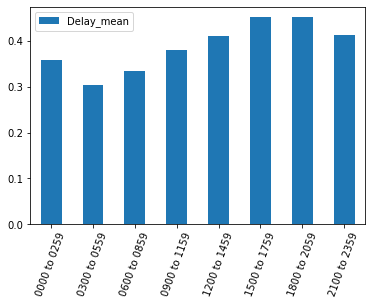

In [51]:
ax = daily_df.plot.bar(rot=70)

In [53]:
weekday =  {'Delay_mean':[Mondays,Tuesdays,Wednesday,Thursday,Friday,Saturday,Sunday]}
weekday_df = pd.DataFrame(weekday, index =['Monday','Tuesday','Wednesday','Thursday',
                                           'Friday','Saturday','Sunday'])
weekday_df

,Delay_mean
Monday,0.393417
Tuesday,0.378415
Wednesday,0.395972
Thursday,0.438425
Friday,0.453488
Saturday,0.357183
Sunday,0.402834


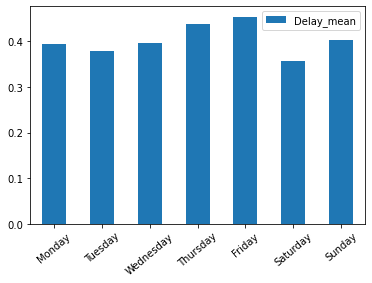

In [55]:
ax = weekday_df.plot.bar(rot=40)

In [31]:
Month =  {'Delay_mean':[Jan,Feb,Mar,Apr,May,June,July,Aug,Sep,Nov,Dec]}
Month_df = pd.DataFrame(Month, index =['Jan','Feb','Mar','Apr','May','June',
                                       'July','Aug','Sep','Nov','Dec'])
Month_df

,Delay_mean
Jan,0.419428
Feb,0.432120
Mar,0.438928
Apr,0.389741
May,0.382042
June,0.433832
July,0.422172
Aug,0.417158
Sep,0.314700
Nov,0.379280


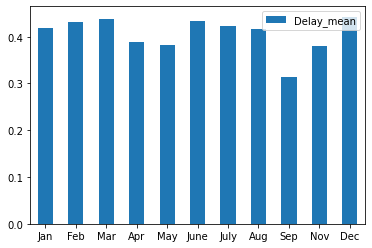

In [32]:
ax = Month_df.plot.bar(rot=0)

##  Conclusion

In [61]:
x = str(round(HR0305, 3)*100)+'%'
y = str(round(Saturday, 4)*100)+'%'
z = str(round(Sep, 4)*100)+'%'

print("The best time of the day to fly is between 0300hr to 0600hr as it has the lowest delay probability of", x)
print("The best day of the week to fly is Saturdays as it has the lowest delay probability of", y)
print("The best time of the year to fly is around September as it has the lowest delay probability of", z)

The best time of the day to fly is between 0300hr to 0600hr as it has the lowest delay probability of 30.3%
The best day of the week to fly is Saturdays as it has the lowest delay probability of 35.72%
The best time of the year to fly is around Septemberit has the lowest delay probability of 31.47%


In [ ]:
conn.close()